<a href="https://colab.research.google.com/github/tetianaboyko3/Python-practice/blob/main/Tetiana_Boiko_11_2__%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Matplotlib_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('drive/MyDrive/Files/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.head(10)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,1,1,Saturday,5,52,2011,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,1,2,Saturday,5,52,2011,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,1,3,Saturday,5,52,2011,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,1,4,Saturday,5,52,2011,1
2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1,1,5,Saturday,5,52,2011,1
2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2,1,6,Saturday,5,52,2011,1
2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3,1,7,Saturday,5,52,2011,1
2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8,1,8,Saturday,5,52,2011,1


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [ ]:
monthly_avg = df.resample('MS').mean(numeric_only=True)['count']

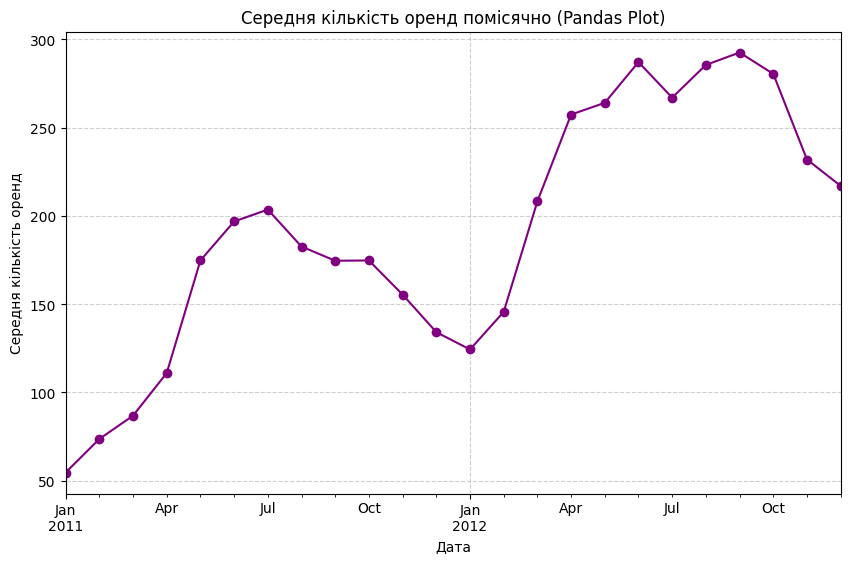

In [ ]:
# Побудова графіка за допомогою Pandas: додаємо маркери-кружечки ('o')
monthly_avg.plot(
    kind='line',
    marker='o',
    figsize=(10,6),
    color='purple',
    title='Середня кількість оренд помісячно (Pandas Plot)',
    ylabel='Середня кількість оренд',
    xlabel='Дата'
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


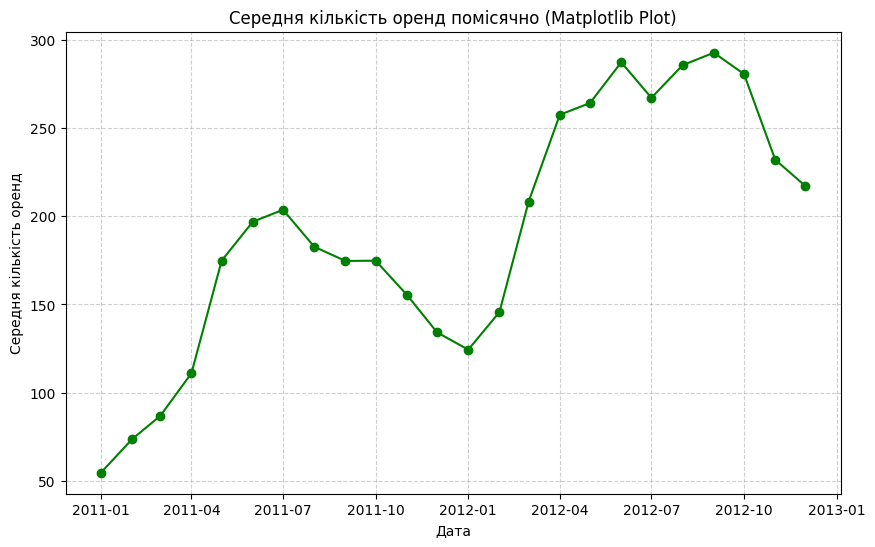

In [ ]:
plt.figure(figsize=(10, 6))

# Побудова графіка за допомогою Matplotlib
plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker='o',
    color='green',
    linestyle='-'
)

# Додавання підписів та заголовка вручну
plt.title('Середня кількість оренд помісячно (Matplotlib Plot)')
plt.xlabel('Дата')
plt.ylabel('Середня кількість оренд')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


✅**Висновок:**

Візуально графіки мають ідентичну форму, відображають ті самі дані та сезонні тренди. Використані кольори будуть різними (фіолетовий проти зеленого у прикладах вище), що було задано вручну.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [ ]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

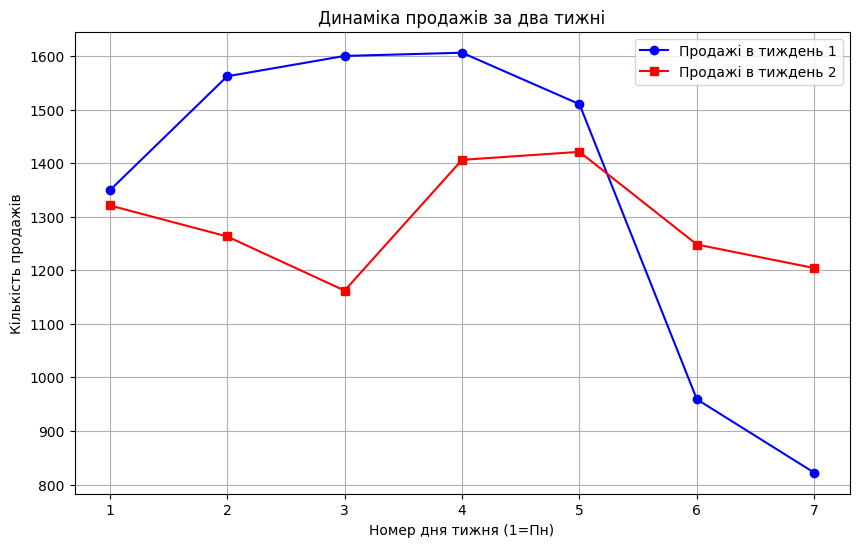

In [ ]:
# Створення графіка
plt.figure(figsize=(10, 6))

# Побудова лінійних графіків різних кольорів з підписами
plt.plot(days, sales_week1, label='Продажі в тиждень 1', color='blue', marker='o')
plt.plot(days, sales_week2, label='Продажі в тиждень 2', color='red', marker='s')

# Додавання назви графіку, підписів вісям та легенди
plt.title('Динаміка продажів за два тижні')
plt.xlabel('Номер дня тижня (1=Пн)')
plt.ylabel('Кількість продажів')
plt.legend()
plt.grid(True) # Додаємо сітку

# Відображення графіка
plt.show()


✅**Висновок**:

1. Судячи з графіку, продажі були стабільнішими в Тиждень 2.
Лінія, що представляє Тиждень 2 (червона), має менші коливання та менший загальний діапазон значень порівняно з Тижнем 1 (синя), де спостерігається значний спад наприкінці тижня.
2. Так, висновок можна підкріпити обчисленнями, а саме — розрахунком стандартного відхилення  для обох наборів даних.


In [ ]:
import statistics as stat
# Розрахунок середнього значення (mean)
mean1 = np.mean(sales_week1)
mean2 = np.mean(sales_week2)

# Розрахунок стандартного відхилення (standard deviation, stdev)
# Використовуємо statistics.stdev для вибірки
std1 = stat.stdev(sales_week1)
std2 = stat.stdev(sales_week2)

print(f"Тиждень 1: Середнє = {mean1:.2f}, Стандартне відхилення = {std1:.2f}")
print(f"Тиждень 2: Середнє = {mean2:.2f}, Стандартне відхилення = {std2:.2f}")


Тиждень 1: Середнє = 1344.00, Стандартне відхилення = 324.04
Тиждень 2: Середнє = 1289.29, Стандартне відхилення = 98.19


**✅Висновок:**

Результати обчислень покажуть, що стандартне відхилення для Тижня 2 буде значно нижчим, ніж для Тижня 1, що підтверджує візуальний висновок про більшу стабільність продажів у другий тиждень.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

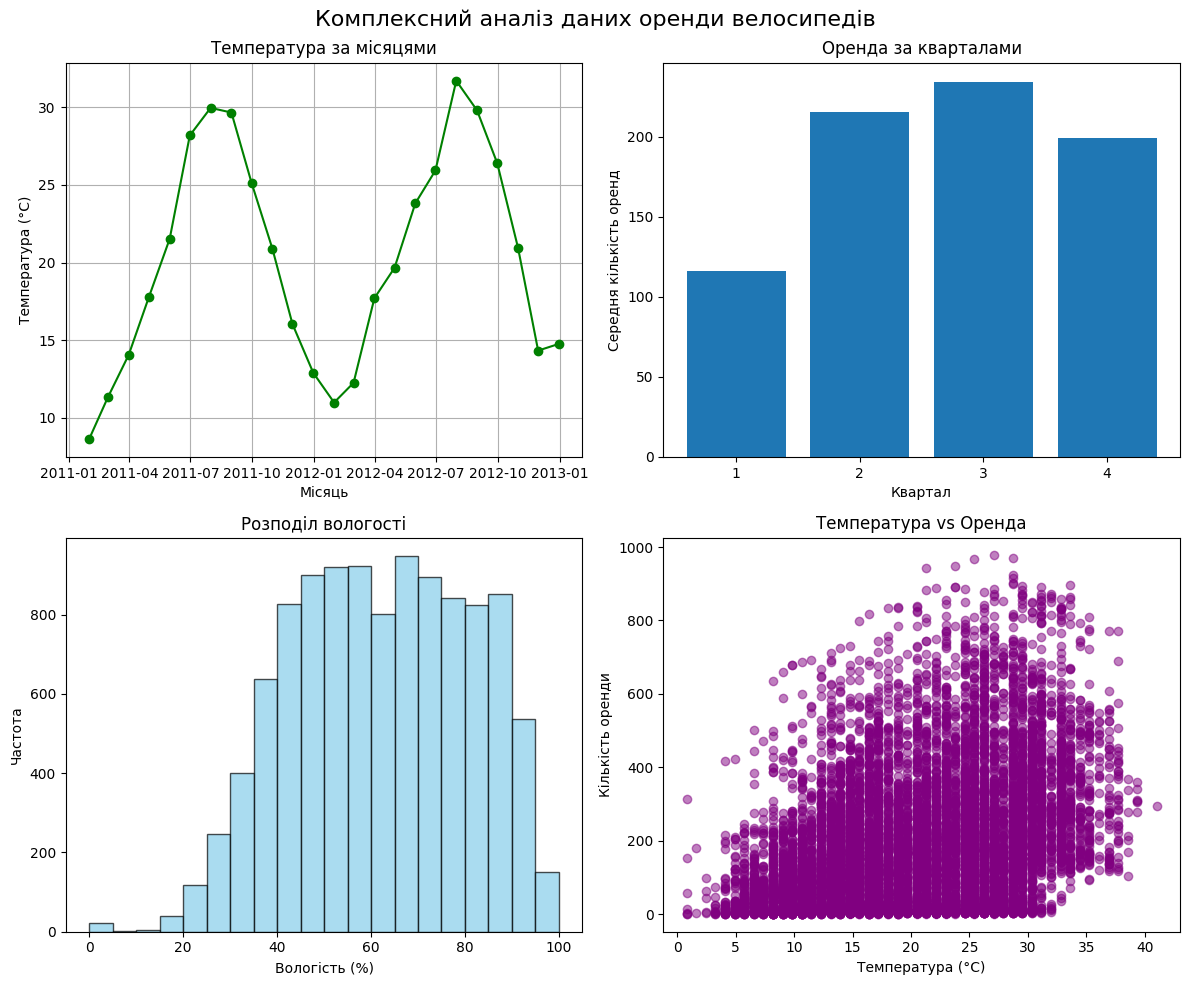

In [ ]:
monthly_temp = df['temp'].resample('ME').mean()
seasonal_count = df.groupby('season')['count'].mean()

plt.figure(figsize=(12, 10))

# Графік 1: Лінійний
plt.subplot(2, 2, 1)
plt.plot(monthly_temp.index, monthly_temp.values, 'g-o')
plt.title('Температура за місяцями')
plt.xlabel('Місяць')
plt.ylabel('Температура (°C)')
plt.grid(True)

# Графік 2: Стовпчикова діаграма
plt.subplot(2, 2, 2)
plt.bar(seasonal_count.index, seasonal_count.values)
plt.title('Оренда за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд')
plt.xticks(seasonal_count.index)

# Графік 3: Гістограма
plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=20, color='skyblue', alpha=0.7, edgecolor='black')
plt.title('Розподіл вологості')
plt.xlabel('Вологість (%)')
plt.ylabel('Частота')

# Графік 4: Scatter
plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], alpha=0.5, color='Purple')
plt.title('Температура vs Оренда')
plt.xlabel('Температура (°C)')
plt.ylabel('Кількість оренди')

plt.suptitle('Комплексний аналіз даних оренди велосипедів', fontsize=16)
plt.tight_layout()
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

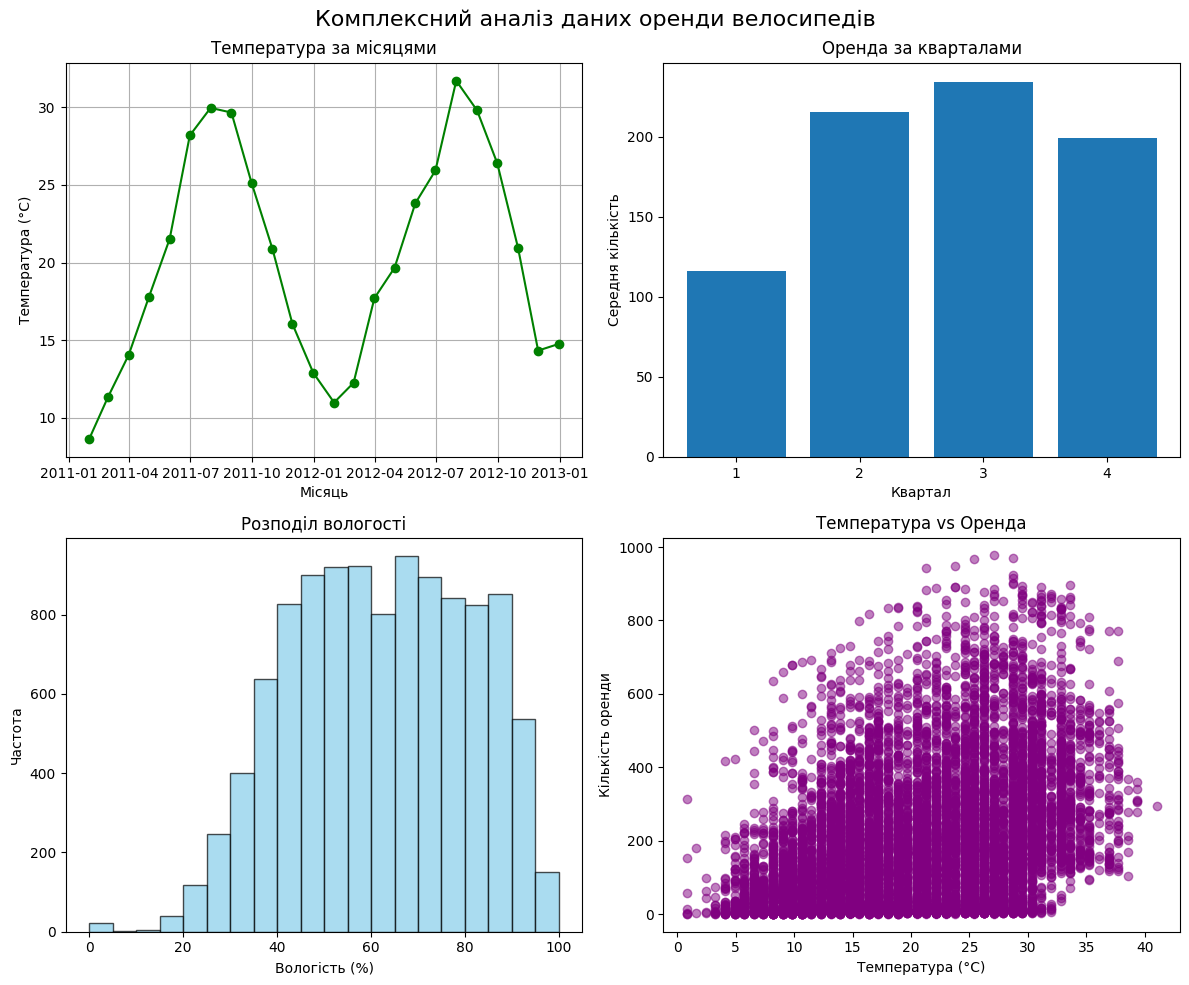

In [ ]:
# Створення сітки 2x2
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# Графік 1: Лінійний (верхній лівий)
ax[0, 0].plot(monthly_temp.index, monthly_temp.values, 'g-o')
ax[0, 0].set_title('Температура за місяцями')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Температура (°C)')
ax[0, 0].grid(True)

# Графік 2: Стовпчикова діаграма (верхній правий)
ax[0, 1].bar(seasonal_count.index, seasonal_count.values)
ax[0, 1].set_title('Оренда за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Середня кількість')
ax[0, 1].set_xticks(seasonal_count.index)

# Графік 3: Гістограма (нижній лівий)
ax[1, 0].hist(df['humidity'], bins=20, color='skyblue', alpha=0.7, edgecolor='black')
ax[1, 0].set_title('Розподіл вологості')
ax[1, 0].set_xlabel('Вологість (%)')
ax[1, 0].set_ylabel('Частота')

# Графік 4: Scatter (нижній правий)
ax[1, 1].scatter(df['temp'], df['count'], alpha=0.5, color='purple')
ax[1, 1].set_title('Температура vs Оренда')
ax[1, 1].set_xlabel('Температура (°C)')
ax[1, 1].set_ylabel('Кількість оренди')

# Загальний заголовок
fig.suptitle('Комплексний аналіз даних оренди велосипедів', fontsize=16)
plt.tight_layout()
plt.show()

✅Висновок:

plt.subplot() використовує процедурний підхід і керує однією віссю одночасно за допомогою глобальних функцій plt..

plt.subplots() повертає об'єкт фігури та масив об'єктів осей, що дозволяє використовувати чистий об'єктно-орієнтований стиль програмування для складних макетів.


## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [ ]:
import matplotlib.dates as mdates

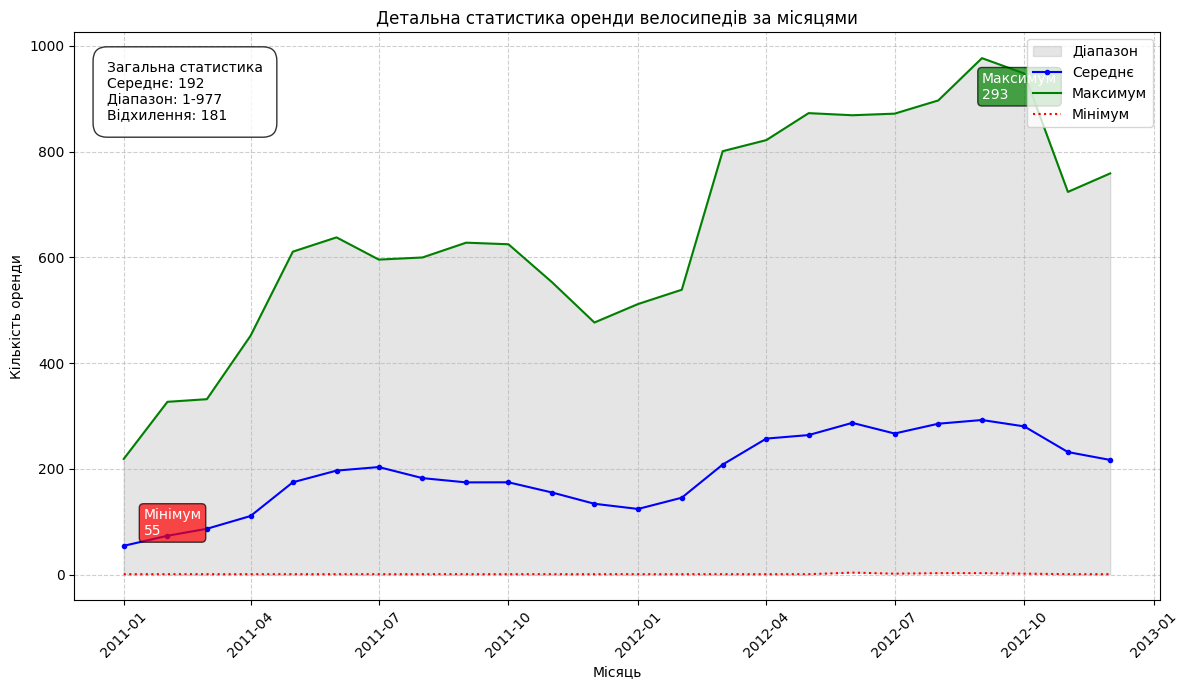

In [ ]:
# Використовуємо resample('MS') для початку місяця
df_monthly = df.resample('MS').agg({
    'count': ['mean', 'max', 'min'],
    'casual': 'mean',
    'registered': 'mean'
})
# Спрощуємо назви колонок
df_monthly.columns = ['count_mean', 'count_max', 'count_min', 'casual_mean', 'registered_mean']

# Розрахунок загальної статистики для текстового блоку
mean_total = df['count'].mean()
min_total = df['count'].min()
max_total = df['count'].max()
std_total = df['count'].std()

# --- ПОБУДОВА ГРАФІКА ---
plt.figure(figsize=(12, 7))
ax = plt.gca() # Отримуємо поточні осі

# 1. Зафарбовані області (Діапазон)
# Заливка між лініями Максимум та Мінімум
plt.fill_between(df_monthly.index, df_monthly['count_min'], df_monthly['count_max'],
                 color='gray', alpha=0.2, label='Діапазон')
# Заливка навколо середньої лінії (наприклад, +/- одне стандартне відхилення, якщо потрібно)
# plt.fill_between(df_monthly.index, df_monthly['count_mean'] - df['count'].std(),
#                  df_monthly['count_mean'] + df['count'].std(), color='purple', alpha=0.1)


# 2. Побудова ліній
plt.plot(df_monthly.index, df_monthly['count_mean'], label='Середнє', color='blue', marker='.')
plt.plot(df_monthly.index, df_monthly['count_max'], label='Максимум', color='green')
plt.plot(df_monthly.index, df_monthly['count_min'], label='Мінімум', color='red', linestyle=':')

# 3. Додавання анотацій (текст на графіку)
# Анотація мінімуму
plt.text(pd.to_datetime('2011-01-15'), 55 + 20, 'Мінімум\n55', color='white',
         bbox=dict(boxstyle="round,pad=0.3", fc="red", alpha=0.7))

# Анотація максимуму
plt.text(pd.to_datetime('2012-09-01'), 900, 'Максимум\n293', color='white',
         bbox=dict(boxstyle="round,pad=0.3", fc="green", alpha=0.7))


# 4. Додавання текстового блоку загальної статистики (як на зображенні)
stats_text = (f"Загальна статистика\n"
              f"Середнє: {mean_total:.0f}\n"
              f"Діапазон: {min_total:.0f}-{max_total:.0f}\n"
              f"Відхилення: {std_total:.0f}")
# Розміщуємо блок в лівому верхньому куті графіка (координати від 0 до 1)
ax.text(0.03, 0.95, stats_text, transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=1', fc='white', alpha=0.8))


# 5. Налаштування осей, заголовків, сітки та легенди
plt.title('Детальна статистика оренди велосипедів за місяцями')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))

# Налаштування формату дат на осі X для відображення тільки року та місяця
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45) # Поворот міток осі X для кращої читабельності

plt.tight_layout()
plt.show()


✅**Висновок:**

1. Основна перевага додавання анотацій (таких як "Максимум 293", "Мінімум 55" або стрілки) полягає в підвищенні інформативності та швидкості сприйняття даних. Вони дозволяють глядачеві миттєво ідентифікувати ключові точки, екстремальні значення або важливі події без необхідності ретельного вивчення осей чи легенди.
2. Функція fill_between() у бібліотеці Matplotlib використовується для заливки області між двома горизонтальними кривими або між кривою та горизонтальною лінією (наприклад, віссю X).
3. Текстовий блок  надає короткий кількісний підсумок ключових статистичних показників, які доповнюють візуальну інформацію. Він допомагає в інтерпретації даних, пропонуючи точні числові значення (агреговані метрики), які неможливо точно визначити "на око" з графіка. Це дозволяє швидко оцінити загальну картину, підтвердити візуальні спостереження точними даними та зробити обґрунтованіші висновки.